<a href="https://colab.research.google.com/github/PatrickOdilonOgue/-Car-Dataset-/blob/Master/ML_Projekt_bus_%2C_van_or_car_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML - Projekt: “Prospect Auto”**



In diesem Projekt implementieren wir ein automatisches Objekterkennungs- und Klassifizierungssystem, das auf geometrischen Merkmalen basiert, die aus der Silhouette von Fahrzeugen aus verschiedenen Blickwinkeln extrahiert sind: ein Bus (ein Doppeldeckerbus), ein Lieferwagen (ein Cheverolet-Lieferwagen) und ein Auto (entweder Saab 9000 oder Opel Manta). Insgesamt haben wir eine Reihe von 18 geometrischen Merkmalen, von denen die wichtigsten die folgenden sind:

*   Compactness: Misst die Dichte der Kontur im Verhältnis zu ihrer Fläche
*   Circularity: Beurteilt die Ähnlichkeit mit einem perfekten Kreis
*   Elongatedness: Bezeichnet den Grad der Streckung des Objekts.
*   pr.axis_aspect_ratio: Das Verhältnis der Länge zur Breite der Ellipse, die das Objekt approximiert.
*   Hollows_ratio: Misst das Vorhandensein von Vertiefungen oder Hohlräumen in der Form.
*   Distance_circularity: Maß für die Abweichung.
*   Max.length_aspect_ratio : Verhältnis der maximalen Abmessungen.
*   Scatter_ratio. : Streuung der Punkte

Einige Merkmale weisen aufgrund ihrer ähnlichen Natur Korrelationen und Interdependenzen auf:
```
#  Compactness, Circularity und Distance_circularity sind mit der Regelmäßigkeit der Kontur verbunden.
#  pr.axis_aspect_ratio, max.length_aspect_ratio und Elongatedness konzentrieren sich auf die Streckung.

```
Aus diesem Grund haben wir diese Merkmale entsprechend ihrer potenziellen Bedeutung klassifiziert:
```
  ~ Hohes Level: Circularity, Compactness, Elongatedness, pr.axis_aspect_ratio, Hollows_ratio.
  ~ Mittleres Level: Distance_circularity, max.length_aspect_ratio, Scatter_ratio
  ~ ErgänzendeEbenen: Scaled_variance, Scaled_radius_of_gyration, Skewness_about (und ihre Varianten).
```

Die 8 Features, die für unser Marchine learning Model als wesentlich erachtet werden, sind die von **Hohes Level** und **Mittleres Level**, da sie eine effiziente Erfassung der meisten geometrischen und strukturellen Eigenschaften für die Feinklassifikation von Objekten ermöglichen werden.

Unser Ansatz basiert auf **Supervised Learning**, das für diese Art von Klassifikationsproblemen besonders geeignet ist.
Der in diesem Projekt entwickelte Python-Code wird sich beschäftigt mit der `Extraktion` dieser Features, ihrer `Normalisierung` und dem `Training eines Klassifikationsmodells`. Ziel ist es am Ende, ein robustes und interpretierbares System zu schaffen, das in der Lage ist, verschiedene Arten von Objekten(Klasse): `Bus`, `Car`, `Van` allein aufgrund ihrer Geometrie zu unterscheiden.


In [ ]:
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# utility
from pprint import pprint
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report,make_scorer, mean_squared_error, mean_absolute_error, r2_score, max_error, mean_absolute_percentage_error
from scipy.stats import mode


# Data

In [ ]:
# Laden eines Beispiel-Datensatzes
data = pd.read_csv("vehicle.csv")

# Anzeige der ersten Zeilen des Datensatzes
print("Erste Zeilen des Datensatzes:")
print(data.shape)

# Die tatsächlichen Spaltennamen aus dem Datenrahmen abrufen
print("\nSpaltennamen des Datensatzes:")
print(data.columns)

# Entfernen irrelevanter Spalten
data.drop(columns=['radius_ratio', 'pr.axis_rectangularity', 'max.length_rectangularity','scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration','scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1','skewness_about.2'], inplace=True)

# Anzeige der zweite Zeilen des Datensatze und neuer Spaltennamen des Datensatzes
print("\n Neuer Spaltennamen des Datensatzes:")
print(data.columns) ; print(data.shape)


Erste Zeilen des Datensatzes:
(846, 19)

Spaltennamen des Datensatzes:
Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')

 Neuer Spaltennamen des Datensatzes:
Index(['compactness', 'circularity', 'distance_circularity',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'hollows_ratio', 'class'],
      dtype='object')
(846, 9)


# Check for missing values and duplicates

In [ ]:
data.isna().sum()

,0
compactness,0
circularity,5
distance_circularity,4
pr.axis_aspect_ratio,2
max.length_aspect_ratio,0
scatter_ratio,1
elongatedness,1
hollows_ratio,0
class,0


In [ ]:
print(data.shape) # original daten
print(data.drop_duplicates().shape) # daten ohne duplicates

(846, 9)
(845, 9)


Es gibt 1 doppelten Wert und 13 fehlende Werte.

In [ ]:
# Umgang mit fehlenden Werten
data.dropna(inplace=True)

data


,compactness,circularity,distance_circularity,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,hollows_ratio,class
0,95,48.0,83.0,72.0,10,162.0,42.0,197,van
1,91,41.0,84.0,57.0,9,149.0,45.0,199,van
2,104,50.0,106.0,66.0,10,207.0,32.0,196,car
3,93,41.0,82.0,63.0,9,144.0,46.0,207,van
4,85,44.0,70.0,103.0,52,149.0,45.0,183,bus
...,...,...,...,...,...,...,...,...,...
841,93,39.0,87.0,64.0,8,169.0,40.0,195,car
842,89,46.0,84.0,66.0,11,159.0,43.0,197,van
843,106,54.0,101.0,67.0,12,222.0,30.0,201,car
844,86,36.0,78.0,58.0,7,135.0,50.0,195,car


# Train Test Split

In [ ]:
train, test = train_test_split(data, test_size=0.12, stratify=data['class'], random_state=19)

print('train shape: ', train.shape)
print('test shape: ', test.shape)

train.head(2)

train shape:  (733, 9)
test shape:  (101, 9)


,compactness,circularity,distance_circularity,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,hollows_ratio,class
138,88,37.0,63.0,58.0,5,125.0,54.0,188,car
18,104,54.0,100.0,61.0,10,216.0,31.0,195,car


# EDA

In [ ]:
train.describe()

,compactness,circularity,distance_circularity,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,hollows_ratio
count,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000,733.000000
mean,93.470668,44.672578,81.693042,61.639836,8.556617,167.718963,41.171896,195.691678
std,8.125436,6.143705,15.704318,7.691891,4.658693,32.799567,7.738762,7.479509
min,73.000000,33.000000,40.000000,47.000000,2.000000,112.000000,26.000000,181.000000
25%,87.000000,40.000000,70.000000,57.000000,7.000000,146.000000,34.000000,191.000000
50%,92.000000,44.000000,79.000000,61.000000,8.000000,156.000000,43.000000,197.000000
75%,99.000000,49.000000,98.000000,65.000000,10.000000,196.000000,46.000000,201.000000
max,119.000000,59.000000,112.000000,138.000000,55.000000,265.000000,61.000000,211.000000


In [ ]:
class_counts = data['class'].value_counts()
print(class_counts)

class
car    425
bus    211
van    198
Name: count, dtype: int64


In [ ]:
train['class'].value_counts(normalize=True)

,proportion
class,
car,0.510232
bus,0.252387
van,0.237381


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Genauigkeit des Modells: 0.7822
Klassifikationsbericht:
              precision    recall  f1-score   support

         bus       0.75      0.69      0.72        26
         car       0.77      0.84      0.80        51
         van       0.86      0.75      0.80        24

    accuracy                           0.78       101
   macro avg       0.79      0.76      0.77       101
weighted avg       0.78      0.78      0.78       101



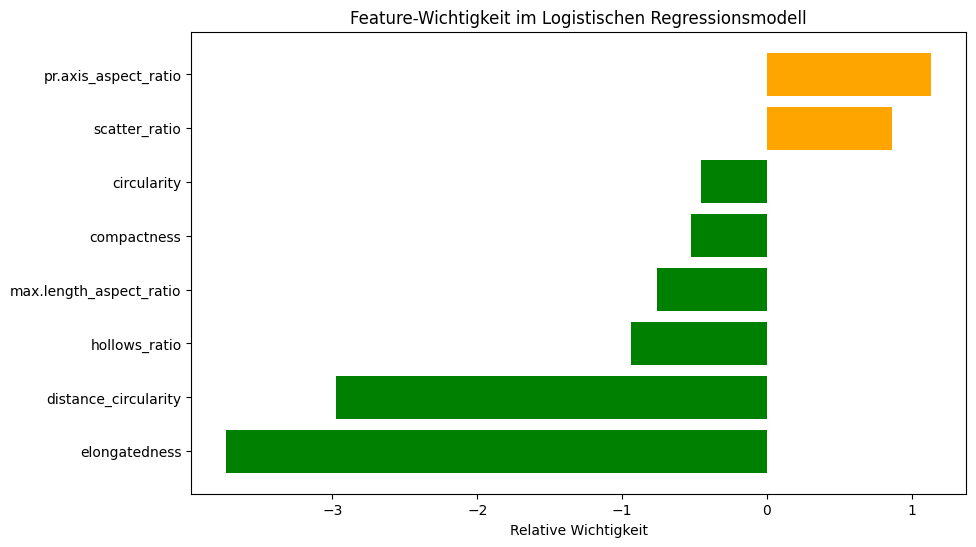

Accuracy: 0.7821782178217822
Confusion Matrix:
 [[18  7  1]
 [ 6 43  2]
 [ 0  6 18]]
Precision: 0.7844766619519096
Recall: 0.7821782178217822
F1-Score: 0.7812936059961135
ROC AUC Score: 0.940964382152501


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

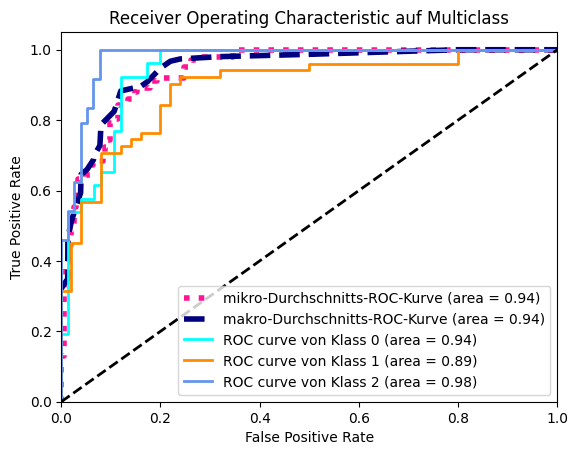

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Features und Target definieren
X = data.drop('class', axis=1)  # Features
y = data['class']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, stratify=y, random_state=19)

# Standardisierung numerischer Features
# Der StandardScaler skaliert die numerischen Werte so, dass sie einen Mittelwert von 0 und eine Standardabweichung von 1 haben.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Modell definieren
# Wir nutzen einen LogisticRegression,mit "Multinomial" für die Klassifizierung mehrerer Klassen (3)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# Modell trainieren
# Das Modell wird mit den Trainingsdaten trainiert, indem es Muster in den Daten lernt.
model.fit(X_train, y_train)

# Vorhersagen treffen
# Mit den Testdaten lassen wir unser Modell Vorhersagen treffen.
y_pred = model.predict(X_test)
# zuzätliche um die vorhergesagten Wahrscheinlichkeiten zu erhalten, die für roc_auc_score benötigt werden.
y_prob = model.predict_proba(X_test)

# Evaluation
# Die Leistung des Modells wird anhand von Metriken wie der Genauigkeit und des Klassifikationsberichts bewertet.
accuracy = accuracy_score(y_test, y_pred)
print(f'Genauigkeit des Modells: {accuracy:.4f}')
print('Klassifikationsbericht:')
print(classification_report(y_test, y_pred))

# Feature Importance plotten
importance = model.coef_[0]  # Für die logistische Regression mit mehreren Klassen wir verwenden model.coef_[0] für die erste Klasse
feature_names = X.columns  # um die Namen der Features zu erhalten (Ersetzen Sie X durch den Namen Ihres Feature DataFrame)
indices = np.argsort(importance) # Sortieren Sie die Features nach ihrer Bedeutung

# Den Plot erstellen
plt.figure(figsize=(10, 6))
plt.title("Feature-Wichtigkeit im Logistischen Regressionsmodell")

# Create a list of colors based on the sign of importance values
colors = ['orange' if value >= 0 else 'green' for value in importance[indices]]
plt.barh(range(len(indices)), importance[indices], align="center", color=colors)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Wichtigkeit")
plt.show()

# Die Feature Importance zeigt, welche Features am wichtigsten für die Vorhersage waren.
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))  # weighted pour multi-classes
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))

# ROC AUC Score (bei Mehrklassenproblemen verwende 'ovr'
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print("ROC AUC Score:", roc_auc)


# Zielvariable binarisieren
y_test_bin = label_binarize(y_test, classes=model.classes_)
n_classes = y_test_bin.shape[1]

# One-vs-Rest Classifier erstellen
classifier = OneVsRestClassifier(model)

# Vorhersagen für alle Klassen berechnen
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

# ROC-Kurve und AUC für jede Klasse berechnen
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Mikro-gemittelte ROC-Kurve und AUC berechnen
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Makro-gemittelte ROC-Kurve und AUC berechnen
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolieren Sie dann alle ROC-Kurven an diesen Punkten
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Schließlich wird der Mittelwert gebildet und der AUC berechnet
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ROC-Kurven plotten
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="mikro-Durchschnitts-ROC-Kurve (area = {0:0.2f})".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="makro-Durchschnitts-ROC-Kurve (area = {0:0.2f})".format(roc_auc["macro"]),
    color="navy",
    linestyle="--",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label="ROC curve von Klass {0} (area = {1:0.2f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic auf Multiclass")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Hyperparameter-grid definieren
param_grid = {
    'penalty': ['l1', 'l2'],  # Art der Regularisierung
    'C': [0.1, 1, 10],  # Inverse der Regularisierungsstärke
    'solver': ['liblinear', 'saga']  # Solver für die l1-Regularisierung
}

# Modell erstellen
model = LogisticRegression(multi_class='multinomial')

# GridSearchCV-Objekt erstellen
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Modell mit GridSearchCV trainieren
grid_search.fit(X_train, y_train)

# Beste Hyperparameter anzeigen
print("Beste Hyperparameter:", grid_search.best_params_)

# Modell mit den besten Hyperparametern bewerten
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# Bewertungsmetriken berechnen
accuracy = accuracy_score(y_test, y_pred)
# ... (andere Metriken) ...

# Ergebnisse und Kommentare anzeigen
accuracy = accuracy_score(y_test, y_pred)
print(f'Genauigkeit des Modells: {accuracy:.4f}')
print('Klassifikationsbericht:')
print(classification_report(y_test, y_pred))

# ... (andere Metriken anzeigen) ...

print("Konfusionsmatrix:\n", confusion_matrix(y_test, y_pred))
print("Präzision:", precision_score(y_test, y_pred, average='weighted'))  # weighted für Mehrklassen
print("Sensitivität:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))

# Vergleich mit einem optimalen Ergebnis (zu definieren)
optimal_accuracy = 0.95  # Beispiel für ein optimales Ergebnis

if accuracy >= optimal_accuracy:
    print("Das Modell hat eine optimale Leistung erreicht.")
else:
    print(f"Das Modell hat die optimale Leistung nicht erreicht. Es gibt eine Abweichung von {optimal_accuracy - accuracy:.2f} in der Genauigkeit.")
    # Verbesserungsvorschläge:
    print("Verbesserungsvorschläge:")
    print("- Weitere Hyperparameter untersuchen.")
    print("- Andere Klassifikationsmodelle ausprobieren.")
    print("- Feature-Engineering hinzufügen.")
    print("- Die Größe des Datensatzes erhöhen.")

```
Beste Hyperparameter:
{'C': 10, 'penalty': 'l1', 'solver': 'saga'}
```
```
Genauigkeit des Modells: 0.7822
```
Klassifikationsbericht:

              precision    recall  f1-score   support

         bus       0.70      0.73      0.72        26
         car       0.77      0.80      0.79        51
         van       0.90      0.79      0.84        24

    accuracy                            0.78       101
    macro avg       0.79      0.78      0.78       101
    weighted avg    0.79      0.78      0.78       101

```
Konfusionsmatrix:
 [[19  7  0]
 [ 8 41  2]
 [ 0  5 19]]
```

```
  Präzision:   0.7867664574184283
  Sensitivität: 0.7821782178217822
  F1-Score: 0.7833635105165088
```



Das Modell hat die optimale Leistung nicht erreicht. Es gibt eine Abweichung von 0.17 in der Genauigkeit.

Verbesserungsvorschläge:
- Weitere Hyperparameter untersuchen.
- Andere Klassifikationsmodelle ausprobieren.
- Feature-Engineering hinzufügen.
- Die Größe des Datensatzes erhöhen.

# Gradient Boosting (GB)

In [ ]:

# Load dataset
# Features und Target definieren
X = data.drop('class', axis=1)  # Features
y = data['class']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, stratify=y, random_state=19)

# Gradient Boosting
n_estimators = 100
learning_rate = 0.1
max_depth = 3

# LabelEncoder erstellen und Zielvariable transformieren
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Gradient Boosting Classifier erstellen
gb_classifier = GradientBoostingClassifier(n_estimators=n_estimators,
                                         learning_rate=learning_rate,
                                         max_depth=max_depth,
                                         random_state=19)

# Modell trainieren
gb_classifier.fit(X_train, y_train_encoded)

# Vorhersagen treffen
y_pred_encoded = gb_classifier.predict(X_test)

# Bewerten des Modells
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"Accuracy: {accuracy:.4f}")

# Optional: Zurücktransformieren der Vorhersagen in die ursprünglichen Klassenlabels
y_pred = label_encoder.inverse_transform(y_pred_encoded)
print(classification_report(y_test, y_pred))

Accuracy: 0.9901
              precision    recall  f1-score   support

         bus       1.00      1.00      1.00        26
         car       1.00      0.98      0.99        51
         van       0.96      1.00      0.98        24

    accuracy                           0.99       101
   macro avg       0.99      0.99      0.99       101
weighted avg       0.99      0.99      0.99       101



# Kreuzvalidierung

In [ ]:
# Load dataset
# Features und Target definieren
X = data.drop('class', axis=1)  # Features
y = data['class']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, stratify=y, random_state=19)

# Gradient Boosting Classifier erstellen
gb_classifier = GradientBoostingClassifier(n_estimators=100,
                                         learning_rate=0.1,
                                         max_depth=3,
                                         random_state=19)

# LabelEncoder erstellen und Zielvariable transformieren
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Kreuzvalidierung mit 5 Faltungen und Accuracy als Metrik
scores = cross_val_score(gb_classifier, X, y_encoded, cv=5, scoring='accuracy')

# Ergebnisse anzeigen
print("Kreuzvalidierungs-Scores:", scores)
print("Mittlere Genauigkeit:", scores.mean())
print("Standardabweichung:", scores.std())

# Cross-validation mit mehreren Metriken
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

cv_results = cross_validate(gb_classifier, X, y_encoded, cv=5, scoring=scoring)

# Ergebnisse anzeigen
print("Kreuzvalidierungsergebnisse (Trainingsset):")
for metric in scoring.keys():
    score = np.mean(cv_results['test_' + metric])
    std_dev = np.std(cv_results['test_' + metric])
    print(f"{metric}: {score:.3f} ± {std_dev:.3f}")

# Modell auf dem gesamten Trainingsdatensatz trainieren
gb_classifier.fit(X_train, y_train_encoded)

# Modell auf dem Testdatensatz evaluieren
y_pred_encoded = gb_classifier.predict(X_test)

# Accuracy berechnen
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"Accuracy auf dem Testdatensatz: {accuracy:.4f}")

Kreuzvalidierungs-Scores: [0.94011976 0.94610778 0.97005988 0.91017964 0.95783133]
Mittlere Genauigkeit: 0.9448596782338937
Standardabweichung: 0.020149657070185668
Kreuzvalidierungsergebnisse (Trainingsset):
accuracy: 0.945 ± 0.020
precision: 0.945 ± 0.020
recall: 0.945 ± 0.020
f1: 0.945 ± 0.020
Accuracy auf dem Testdatensatz: 0.9901


##„Prospect Auto“,
suchte nach einer Lösung zur Automatisierung der Fahrzeugklassifizierung. Die Herausforderung bestand darin, die Fahrzeugtypen genau zu identifizieren und zu klassifizieren, um den Fuhrpark zu optimieren und intelligent zu verwalten. Die automatische Klassifizierung von Fahrzeugen in verschiedene Kategorien (Bus, Pkw, Lieferwagen) war daher der Kern des Projekts, das wir durchgeführt haben.

Die Ergebnisse dieser Arbeit werden im folgenden Abschnitt ausführlich dargestellt.

## **Datenstruktur und Aufbereitung**
Die Qualität und die Struktur des Datensatzes waren die grundlegenden Elemente für den Erfolg der Klassifizierungsarbeit.
Der für dieses Projekt verwendete Datensatz weist eine spezifische Verteilung einer Stichprobe von insgesamt 834 Fahrzeugen auf, die in drei Hauptklassen unterteilt sind: 26% Busse, 50% Pkw und 24% Kleintransporter.

##**Bewertungsmethoden**

Die Leistung der Modelle wurde anhand mehrerer sich ergänzender Metriken bewertet: Gesamtgenauigkeit (accuracy), Genauigkeit pro Klasse (precision), Rückrufquote (recall) und F1-Score. Um die Robustheit der Ergebnisse zu gewährleisten und Verzerrungen durch die Datenpartitionierung zu vermeiden, wurde eine Kreuzvalidierung mit fünf Fallzahlen durchgeführt. Diese Methodik ermöglicht es, nicht nur die Rohleistung der Modelle zu bewerten, sondern auch ihre Stabilität und ihre Fähigkeit, auf neue Daten zu verallgemeinern.

Die Analyse der Konfusionsmatrizen liefert wertvolle Informationen über die Leistung der Modelle nach Klassen. Für das Gradient Boosting-Modell sind die Ergebnisse mit einer Genauigkeit von 1,00 für Busse, 1,00 für Pkw und 0,96 für Lieferwagen besonders beeindruckend. Auch der Recall erreicht Spitzenwerte von 1,00 für Busse und Lieferwagen und 0,98 für Pkw. Diese Ergebnisse zeigen, dass das Modell in der Lage ist, die verschiedenen Fahrzeugklassen korrekt zu identifizieren, wobei nur sehr wenige Fehlklassifikationen auftreten.
Der F1-Score, der den harmonischen Mittelwert aus Genauigkeit und Recall darstellt, bestätigt die hervorragende Leistung des Gradient Boosting-Modells mit Werten von 1,00 für Busse, 0,99 für Pkw und 0,98 für Kleintransporter. Diese Ergebnisse weisen auf ein optimales Gleichgewicht zwischen Genauigkeit und Rückgewinnung für jede Klasse hin, trotz der unausgewogenen Verteilung des Datensatzes.

##**Stabilität der Modelle**
Kreuzvalidierung mit fünf Falten wurde verwendet, um die Stabilität der Modellleistung bei unterschiedlichen Datenpartitionen zu bewerten. Die Ergebnisse zeigen, dass das Gradient Boosting Modell eine hohe und stabile Leistung über die verschiedenen Falten beibehält, mit einer durchschnittlichen Genauigkeit von 0,945 und einer relativ geringen Standardabweichung von 0,0201. Diese Stabilität ist ein wichtiger Indikator für die Robustheit des Modells und seine Fähigkeit, auf neue
Daten zu verallgemeinern.
Die Kreuzvalidierungswerte für Gradient Boosting schwanken zwischen 0,910 und 0,970, was auf eine gewisse Variabilität hinweist, aber immer noch in einem sehr guten Bereich liegt. Diese Konsistenz stärkt das Vertrauen in die Prognosefähigkeit des Modells für reale Anwendungen.

Bewertung der Leistung
Die vergleichende Analyse der getesteten Modelle zeigt erhebliche Leistungsunterschiede sowohl in der Gesamtgenauigkeit als auch in der Fähigkeit, jede Fahrzeugklasse korrekt zu identifizieren. Dieser Abschnitt enthält eine Zusammenfassung der Ergebnisse und eine detaillierte Analyse der Stärken und Schwächen der einzelnen Ansätze.

##**Zusammenfassung der Ergebnisse**
Die durchgeführten Experimente zeigten eine klare Hierarchie zwischen den verschiedenen Klassifizierungsansätzen, wobei das Gradient Boosting eine außergewöhnliche Genauigkeit von 99,01% erreichte. Diese Leistung übertrifft signifikant die der evaluierten logistischen Regression und bestätigt die besondere Eignung dieses Ansatzes für die Klassifizierung von Fahrzeugen auf Basis physikalischer und funktionaler Merkmale.
Die Optimierung der Hyperparameter führte zu einer deutlichen Verbesserung der Leistungsfähigkeit dieser Modelle. Für die logistische Regression wurden C=10, penalty='l1' und solver='saga' als die besten Hyperparameter identifiziert. Diese Konfiguration bietet ein gutes Gleichgewicht zwischen der Fähigkeit des Modells, sich an die Trainingsdaten anzupassen, und seiner Fähigkeit, auf neue Beobachtungen zu verallgemeinern.
Für das Gradient Boosting Modell hat die Optimierung eine besonders leistungsfähige Konfiguration identifiziert, die dazu beiträgt, die außergewöhnliche Genauigkeit von 99,01% zu erreichen. Zu den optimalen Hyperparametern gehören insbesondere eine hohe Anzahl von Schätzern in Kombination mit einer moderaten Baumtiefe und einer relativ geringen Lernrate, was eine schrittweise Konvergenz zur optimalen Lösung ermöglicht.
Schlussfolgerung und Ausblick
Gradient Boosting ist das Modell, das eine bemerkenswerte Effizienz im maschinellen Lernen bieten kann und besonders für diese komplexe Aufgabe der Erkennung und Verlinkung geeignet ist. Für zukünftige Versionen des Systems sind jedoch weitere Verbesserungen denkbar. Zum Beispiel die Entwicklung anderer Modelle wie KNN, SVM, Random Forest oder die Integration von Techniken des kontinuierlichen Lernens, die es dem Modell ermöglichen würden, sich dynamisch an neue gesammelte Daten anzupassen und so seine Genauigkeit und Robustheit schrittweise zu verbessern. Dieser Ansatz ist besonders für Umgebungen relevant, in denen sich die Verteilung der Fahrzeugtypen im Laufe der Zeit ändern kann.
Eine weitere Verbesserung könnte darin bestehen, das System auf feinere Klassifizierungen auszudehnen, die z.B. zwischen verschiedenen PKW-Modellen oder Bussen, Kleinbussen und/oder Elektrobussen (aufgrund ihrer dynamischen Spezifität) unterscheiden. Diese Erweiterung würde wahrscheinlich die Erhebung spezifischerer Trainingsdaten und möglicherweise eine Anpassung der Modellarchitektur erfordern.

In [2]:
!pip freeze > requirements.txt